# Notebook 00d: GEE Data Download

## Overview
This notebook reads the selected periods JSON produced by **Notebook 00c** and downloads
the actual satellite/reanalysis data from Google Earth Engine for each city × variable × date range.

## Workflow
1. User defines which variables to download and which variables must be satisfied **simultaneously**
   (intersection variables). A city is only downloaded if it has valid periods for all intersection variables.
2. For each included city, the date ranges across intersection variables are intersected at the day level
   and re-merged into contiguous ranges — these are the final download windows.
3. For each variable × city × date range, GEE export tasks are submitted to Google Drive using the
   **clipped land-only boundary polygon** from notebook 00a as the export region. This ensures downloaded
   GeoTIFFs contain only the city's land area, not a padded bounding box rectangle.
4. Tasks are monitored and files are downloaded from Drive to the local folder structure.

## Spatial region approach
Consistent with notebooks 00b and 00c, the clipped boundary file produced by 00a is used
to define two GEE geometries per city:
- **`bbox_geom`** — bounding box of the clipped boundary → used for `filterBounds` (fast tile selection)
- **`poly_geom`** — dissolved land-only polygon → used as the export `region` so the output GeoTIFF
  covers the city boundary shape rather than a padded rectangle

## Output structure
All files are downloaded to a Google Drive folder, they should be manually moved to the local folder structure below
```
data/raw/{city}/no2/{city}_no2_YYYY-MM-DD.tif
data/raw/{city}/ntl/{city}_ntl_YYYY-MM-DD.tif
data/raw/{city}/era5_temp/{city}_era5_temp_YYYY-MM-DD.tif
data/raw/{city}/building_height/{city}_building_height.tif
```

## Prerequisites
- Notebook 00a must have produced the clipped boundary files:
  `data/raw/{city}/city_boundary/{city}_boundary_clipped.gpkg`
- Notebook 00b must have produced the missingness CSV
- Notebook 00c must have produced the selected periods JSON
- Google Earth Engine authenticated

---

## 0 · Initialisation

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import sys
import io
import json
import time
import threading
import warnings
from pathlib import Path
from datetime import datetime, timedelta

# ── Third-party ───────────────────────────────────────────────────────────────
import ee
import geopandas as gpd
import json as _json
import pandas as pd

warnings.filterwarnings('ignore')

# ── Project config ────────────────────────────────────────────────────────────
SRC_PATH = Path().resolve().parent / 'src'
sys.path.append(str(SRC_PATH))
from config import DATA_PATH

MISSINGNESS_DIR = DATA_PATH / 'missingness'
print(f'Data root       : {DATA_PATH}')
print(f'Missingness dir : {MISSINGNESS_DIR}')

Data root       : /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data
Missingness dir : /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/missingness


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── USER INPUTS  (edit this cell) ────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Input JSON (output from Notebook 00b) ────────────────────────────────────
# Must match the START_DATE / END_DATE used in 00a and 00b.
START_DATE = '2025-01-01'
END_DATE   = '2025-12-31'

# ── Intersection variables ────────────────────────────────────────────────────
# Variables that MUST all have valid periods for a city to be downloaded.
# A city is excluded if it does not appear in the selected periods for ANY
# of these variables. The final download window per city is the intersection
# of valid date ranges across all listed variables.
#
# Example: if NO₂ is good Jan–Mar and NTL is good Feb–Apr,
#   the intersection is Feb–Mar → only Feb–Mar is downloaded for both.
#
# Set to a single variable to download it without intersection constraints.
INTERSECTION_VARIABLES = ['no2', 'era5_temp'] 

# I THINK IT'S BETTER NOT TO USE NTL otherwise too missing data, also may not be that relevant.

# ── Variables to download ─────────────────────────────────────────────────────
# Define each variable's GEE collection, band, and download settings.
# You can include variables here that are NOT in INTERSECTION_VARIABLES —
# they will be downloaded for the intersected date ranges of the cities
# that passed the intersection check.
#
# scale_m     : export resolution in metres (use native or coarser)
# aggregation : daily composite method — 'mean' or 'median'
VARIABLES = [
    {
        'name'        : 'no2',
        'collection'  : 'COPERNICUS/S5P/OFFL/L3_NO2',
        'band'        : 'tropospheric_NO2_column_number_density',
        'aggregation' : 'mean',
        'scale_m'     : 1000,
        # Google Drive folder for exports — created automatically by GEE
        'drive_folder': 'GEE_NO2',
    },
    {
        'name'        : 'era5_temp',
        'collection'  : 'ECMWF/ERA5_LAND/DAILY_AGGR',
        'band'        : 'temperature_2m',
        'aggregation' : 'mean',
        'scale_m'     : 11132,    # ERA5-Land native resolution ~11km
        'drive_folder': 'GEE_ERA5_TEMP',
    },
    # {
    #     'name'        : 'ntl',
    #     'collection'  : 'NASA/VIIRS/002/VNP46A2',
    #     'band'        : 'DNB_BRDF_Corrected_NTL',
    #     'aggregation' : 'mean',
    #     'scale_m'     : 1000,
    #     'drive_folder': 'GEE_NTL',
    # },
]

# ── GEE settings ──────────────────────────────────────────────────────────────
GEE_PROJECT = 'gen-lang-client-0643926912'   # ← EDIT THIS

# Poll interval in seconds when monitoring GEE export tasks.
# Tasks typically take 1–10 min depending on area and date range.
POLL_INTERVAL_S = 60

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# ── GEE initialisation ────────────────────────────────────────────────────────
ee.Initialize(project=GEE_PROJECT)
print('Earth Engine initialised.')

# ── Load selected periods JSON ────────────────────────────────────────────────
INPUT_JSON = MISSINGNESS_DIR / f'selected_periods_{START_DATE}_{END_DATE}.json'
assert INPUT_JSON.exists(), (
    f'Selected periods JSON not found: {INPUT_JSON}\n'
    f'Run Notebook 00b first.'
)

with open(INPUT_JSON) as f:
    selected_periods = json.load(f)

# Separate metadata from variable data
metadata = selected_periods.pop('_metadata', {})

print(f'\nLoaded: {INPUT_JSON.name}')
print(f'Thresholds used in 00b:')
for k, v in metadata.items():
    print(f'  {k}: {v}')

print(f'\nVariables in JSON : {list(selected_periods.keys())}')
print(f'Intersection vars : {INTERSECTION_VARIABLES}')

Earth Engine initialised.

Loaded: selected_periods_2025-01-01_2025-12-31.json
Thresholds used in 00b:
  source_csv: missingness_2025-01-01_2025-12-31.csv
  start_date: 2025-01-01
  end_date: 2025-12-31
  min_daily_valid_pct: 1.0
  min_year_coverage_pct: 35.0
  min_contiguous_days: 1
  gap_tolerance: 0

Variables in JSON : ['no2', 'era5_temp']
Intersection vars : ['no2', 'era5_temp']


---
## 1 · City & Date Range Intersection

For each city, intersect the valid date ranges across all `INTERSECTION_VARIABLES`.
A city is excluded if it does not appear in any one of the intersection variables.

In [4]:
def ranges_to_date_set(ranges: list) -> set:
    """
    Expand a list of {start, end} range dicts into a set of individual date strings.

    Parameters
    ----------
    ranges : list of dicts with 'start' and 'end' keys ('YYYY-MM-DD')

    Returns
    -------
    Set of 'YYYY-MM-DD' strings covering all days in all ranges
    """
    dates = set()
    for r in ranges:
        day = datetime.strptime(r['start'], '%Y-%m-%d')
        end = datetime.strptime(r['end'],   '%Y-%m-%d')
        while day <= end:
            dates.add(day.strftime('%Y-%m-%d'))
            day += timedelta(days=1)
    return dates


def date_set_to_ranges(date_set: set) -> list:
    """
    Collapse a set of individual date strings back into contiguous {start, end} ranges.

    Parameters
    ----------
    date_set : set of 'YYYY-MM-DD' strings

    Returns
    -------
    Sorted list of {'start': ..., 'end': ..., 'n_days': ...} dicts
    """
    if not date_set:
        return []

    sorted_dates = sorted(datetime.strptime(d, '%Y-%m-%d') for d in date_set)
    ranges = []
    run_start = sorted_dates[0]
    run_end   = sorted_dates[0]

    for d in sorted_dates[1:]:
        if (d - run_end).days == 1:
            run_end = d
        else:
            ranges.append({
                'start' : run_start.strftime('%Y-%m-%d'),
                'end'   : run_end.strftime('%Y-%m-%d'),
                'n_days': (run_end - run_start).days + 1,
            })
            run_start = d
            run_end   = d

    ranges.append({
        'start' : run_start.strftime('%Y-%m-%d'),
        'end'   : run_end.strftime('%Y-%m-%d'),
        'n_days': (run_end - run_start).days + 1,
    })
    return ranges


# ── Compute intersection per city ─────────────────────────────────────────────
# city_download_ranges maps city → list of {start, end, n_days} dicts
# representing the intersected windows to download for that city.
city_download_ranges = {}

# Collect all cities that appear in at least one intersection variable
all_candidate_cities = set()
for var in INTERSECTION_VARIABLES:
    if var in selected_periods:
        all_candidate_cities.update(selected_periods[var].keys())

print(f'Candidate cities across intersection variables: {sorted(all_candidate_cities)}\n')

for city in sorted(all_candidate_cities):
    print(f'── {city} ──────────────────────────────────────────────────')

    # Check city is present in ALL intersection variables
    missing_vars = [
        var for var in INTERSECTION_VARIABLES
        if var not in selected_periods or city not in selected_periods[var]
    ]
    if missing_vars:
        print(f'  EXCLUDED — no valid periods for: {missing_vars}')
        continue

    # Intersect date sets across all intersection variables
    date_sets = [
        ranges_to_date_set(selected_periods[var][city])
        for var in INTERSECTION_VARIABLES
    ]
    intersected_dates = date_sets[0]
    for ds in date_sets[1:]:
        intersected_dates &= ds

    if not intersected_dates:
        print(f'  EXCLUDED — intersection of valid periods across variables is empty')
        continue

    # Re-merge into contiguous ranges
    ranges = date_set_to_ranges(intersected_dates)
    city_download_ranges[city] = ranges

    total_days = sum(r['n_days'] for r in ranges)
    print(f'  INCLUDED — {len(ranges)} range(s), {total_days} days total')
    for r in ranges:
        print(f'    {r["start"]} → {r["end"]}  ({r["n_days"]} days)')

print(f'\n══ {len(city_download_ranges)}/{len(all_candidate_cities)} cities included for download ══')

Candidate cities across intersection variables: ['abuja', 'baghdad', 'buenos_aires', 'cairo', 'cape_town', 'dakar', 'lima', 'los_angeles', 'madrid', 'mexico_city', 'mumbai', 'new_york', 'santiago', 'yangon']

── abuja ──────────────────────────────────────────────────
  INCLUDED — 43 range(s), 285 days total
    2025-01-01 → 2025-03-25  (84 days)
    2025-03-27 → 2025-04-09  (14 days)
    2025-04-11 → 2025-04-24  (14 days)
    2025-04-27 → 2025-04-28  (2 days)
    2025-04-30 → 2025-04-30  (1 days)
    2025-05-02 → 2025-05-16  (15 days)
    2025-05-19 → 2025-05-26  (8 days)
    2025-05-28 → 2025-06-02  (6 days)
    2025-06-04 → 2025-06-12  (9 days)
    2025-06-14 → 2025-06-22  (9 days)
    2025-06-24 → 2025-06-27  (4 days)
    2025-06-29 → 2025-07-03  (5 days)
    2025-07-06 → 2025-07-06  (1 days)
    2025-07-08 → 2025-07-08  (1 days)
    2025-07-10 → 2025-07-12  (3 days)
    2025-07-14 → 2025-07-14  (1 days)
    2025-07-18 → 2025-07-18  (1 days)
    2025-07-22 → 2025-07-22  (1 days)
  

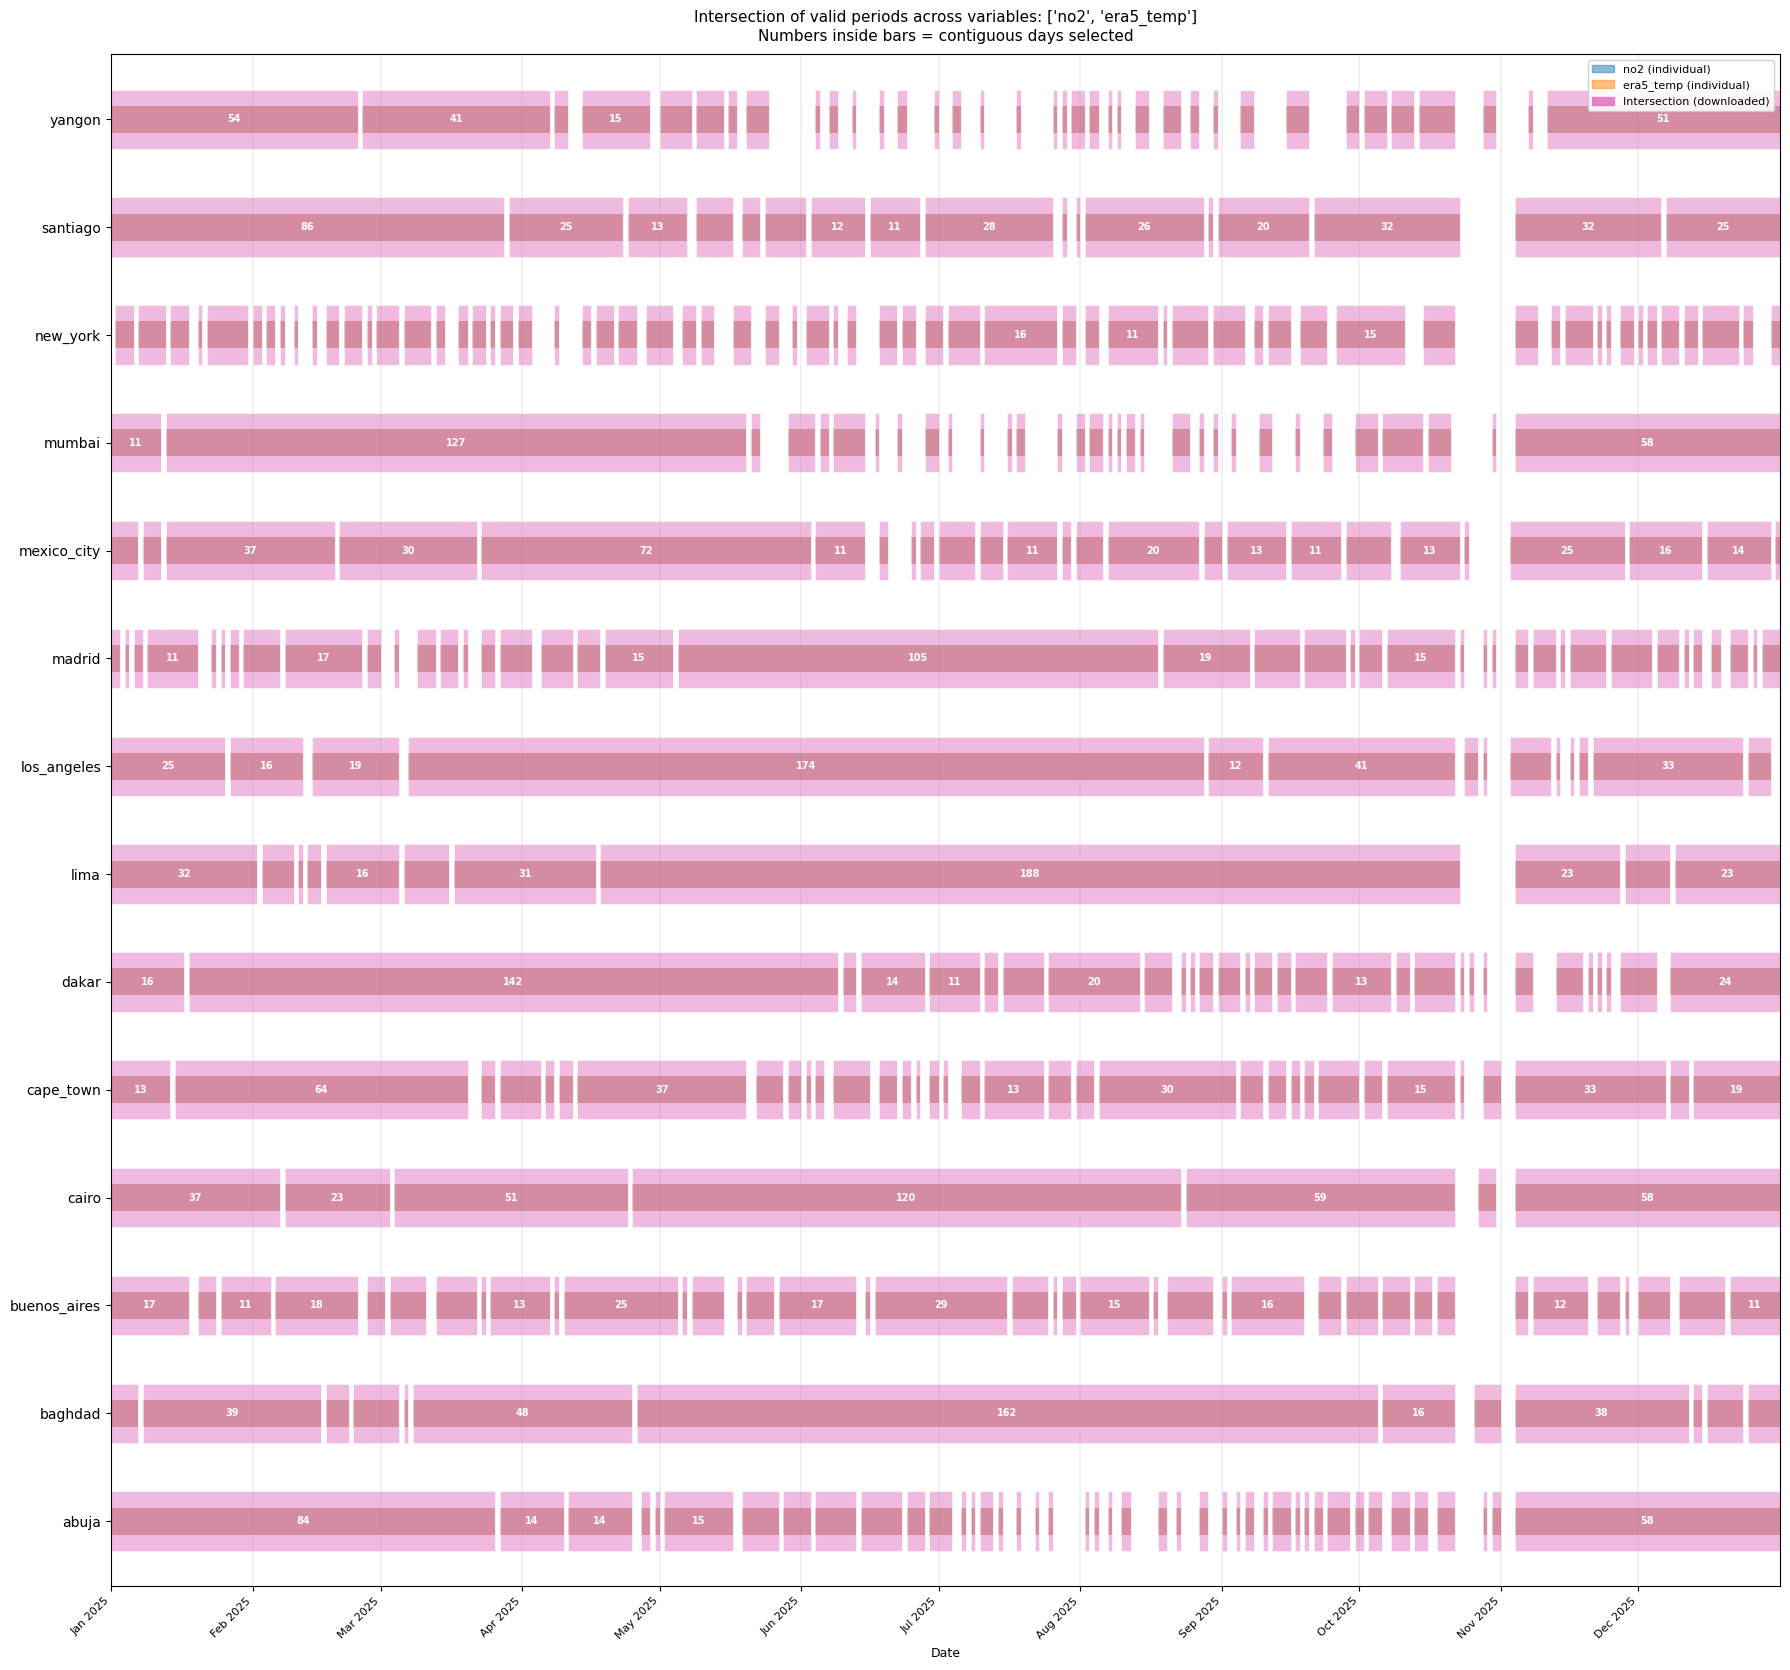

Saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/missingness/intersection_2025-01-01_2025-12-31.pdf


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

period_start = pd.Timestamp(START_DATE)
period_end   = pd.Timestamp(END_DATE)
total_days   = (period_end - period_start).days + 1

cities_included = sorted(city_download_ranges.keys())
n_cities        = len(cities_included)

if n_cities == 0:
    print('No cities passed the intersection — nothing to plot.')
else:
    # ── Colour scheme ─────────────────────────────────────────────────────────
    var_colours = {
        var['name']: colour
        for var, colour in zip(
            VARIABLES,
            ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
        )
    }
    COL_INTERSECTION = '#e377c2'   # pink — final intersected window

    fig, ax = plt.subplots(figsize=(18, max(4, n_cities * 1.2)))

    for yi, city in enumerate(cities_included):
        # ── Per-variable ranges (background context) ──────────────────────────
        for var in INTERSECTION_VARIABLES:
            if var not in selected_periods or city not in selected_periods[var]:
                continue
            colour = var_colours.get(var, '#aec7e8')
            for r in selected_periods[var][city]:
                x_start = (pd.Timestamp(r['start']) - period_start).days
                x_width = (pd.Timestamp(r['end'])   - pd.Timestamp(r['start'])).days + 1
                ax.barh(
                    yi + 0.0, x_width, left=x_start,
                    height=0.25, color=colour, alpha=0.45, linewidth=0,
                )

        # ── Intersected ranges (foreground) ───────────────────────────────────
        for r in city_download_ranges[city]:
            x_start = (pd.Timestamp(r['start']) - period_start).days
            x_width = r['n_days']
            ax.barh(
                yi, x_width, left=x_start,
                height=0.55, color=COL_INTERSECTION, alpha=0.5,
                linewidth=0.8, edgecolor='white',
            )
            # Label with n_days if wide enough
            if x_width > total_days * 0.03:
                ax.text(
                    x_start + x_width / 2, yi,
                    str(r['n_days']),
                    ha='center', va='center', fontsize=7, color='white', fontweight='bold',
                )

    # ── x-axis: monthly ticks ─────────────────────────────────────────────────
    month_starts    = pd.date_range(START_DATE, END_DATE, freq='MS')
    tick_positions  = [(m - period_start).days for m in month_starts]
    tick_labels     = [m.strftime('%b %Y') for m in month_starts]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_xlim(0, total_days)

    # ── y-axis: city names ────────────────────────────────────────────────────
    ax.set_yticks(range(n_cities))
    ax.set_yticklabels(cities_included, fontsize=10)
    ax.set_ylim(-0.6, n_cities - 0.4)

    # ── Vertical month grid ───────────────────────────────────────────────────
    for x in tick_positions:
        ax.axvline(x, color='grey', linewidth=0.3, alpha=0.5)

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(color=var_colours[v], alpha=0.5, label=f'{v} (individual)')
        for v in INTERSECTION_VARIABLES if v in var_colours
    ]
    legend_handles.append(
        mpatches.Patch(color=COL_INTERSECTION, alpha=0.9, label='Intersection (downloaded)')
    )
    ax.legend(handles=legend_handles, fontsize=8, loc='upper right', framealpha=0.9)

    ax.set_title(
        f'Intersection of valid periods across variables: {INTERSECTION_VARIABLES}\n'
        f'Numbers inside bars = contiguous days selected',
        fontsize=11, pad=10,
    )
    ax.set_xlabel('Date', fontsize=9)

    plt.tight_layout()

    fig_path = MISSINGNESS_DIR / f'intersection_{START_DATE}_{END_DATE}.pdf'
    plt.savefig(fig_path, bbox_inches='tight')
    plt.show()
    print(f'Saved → {fig_path}')

---
## 2 · Folder Scaffolding

In [6]:
def make_city_slug(city_name: str) -> str:
    """Convert city name to safe directory string."""
    return city_name.strip().lower().replace(' ', '_').replace(',', '').replace('-', '_')


def file_exists(path: Path) -> bool:
    """Return True if file exists and has non-zero size."""
    return path.exists() and path.stat().st_size > 0


def scaffold_variable_dir(city_slug: str, var_name: str) -> Path:
    """
    Create and return data/raw/{city_slug}/{var_name}/ directory.
    Consistent with the folder structure used in notebook 00_data_retrieval.

    Parameters
    ----------
    city_slug : slugified city name
    var_name  : variable name (e.g. 'no2', 'ntl', 'era5_temp')

    Returns
    -------
    Path to the variable directory (created if not existing)
    """
    d = DATA_PATH / 'raw' / city_slug / var_name
    d.mkdir(parents=True, exist_ok=True)
    return d


# ── Create directories for all included cities × variables ────────────────────
var_dirs = {}   # (city, var_name) → Path

for city in city_download_ranges:
    slug = make_city_slug(city)
    for var in VARIABLES:
        d = scaffold_variable_dir(slug, var['name'])
        var_dirs[(city, var['name'])] = d

print('Folder structure ready.')
for (city, vname), path in var_dirs.items():
    print(f'  {city}/{vname:15s} → {path}')

Folder structure ready.
  abuja/no2             → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/raw/abuja/no2
  abuja/era5_temp       → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/raw/abuja/era5_temp
  baghdad/no2             → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/raw/baghdad/no2
  baghdad/era5_temp       → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/raw/baghdad/era5_temp
  buenos_aires/no2             → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/raw/buenos_aires/no2
  buenos_aires/era5_temp       → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/raw/buenos_aires/era5_temp
  cairo/no2             → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design P

---
## 3 · GEE Export & Download Functions

In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# GEE EXPORT & DRIVE DOWNLOAD FUNCTIONS  (do not edit)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


def load_city_boundary(city_name: str) -> tuple:
    """
    Load the clipped land-only city boundary produced by notebook 00a and
    return both an ee.Geometry bounding box (for GEE filterBounds) and an
    ee.Geometry polygon (for the export region).

    The clipped boundary file is resolved from DATA_PATH using the convention:
        data/raw/{city}/city_boundary/{city}_boundary_clipped.gpkg

    Two-geometry rationale:
        bbox_geom  → filterBounds: fast spatial pre-filter restricting GEE to
                     the relevant image tiles.
        poly_geom  → export region: the exported GeoTIFF covers the land-only
                     city shape rather than the full bounding-box rectangle,
                     reducing file size and excluding sea/lake areas.

    Parameters
    ----------
    city_name : city slug matching the directory name under data/raw/

    Returns
    -------
    (bbox_geom, poly_geom)
        bbox_geom : ee.Geometry.Rectangle — bounding box of the clipped boundary
        poly_geom : ee.Geometry           — land-only boundary polygon

    Raises
    ------
    FileNotFoundError if the clipped boundary file does not exist.
    """
    boundary_path = (
        DATA_PATH / 'raw' / city_name / 'city_boundary'
        / f'{city_name}_boundary_clipped.gpkg'
    )

    if not boundary_path.exists():
        raise FileNotFoundError(
            f"Clipped boundary not found for '{city_name}'.\n"
            f"  Expected: {boundary_path}\n"
            f"  Run notebook 00a first to generate the clipped boundary."
        )

    gdf = gpd.read_file(boundary_path).to_crs('EPSG:4326')

    # Bounding box for filterBounds — fast GEE tile selection
    minx, miny, maxx, maxy = gdf.total_bounds
    bbox_geom = ee.Geometry.Rectangle([minx, miny, maxx, maxy])

    # Dissolved land-only polygon for export region
    if hasattr(gdf.geometry, 'union_all'):
        merged = gdf.geometry.union_all()
    else:
        merged = gdf.unary_union

    poly_geom = ee.Geometry(
        _json.loads(
            gpd.GeoDataFrame(geometry=[merged], crs='EPSG:4326').to_json()
        )['features'][0]['geometry']
    )

    return bbox_geom, poly_geom


def submit_range_tasks(
    city_slug   : str,
    bbox_geom   : 'ee.Geometry',
    poly_geom   : 'ee.Geometry',
    variable    : dict,
    date_ranges : list,
    out_dir     : Path,
) -> list:
    """
    Submit GEE export tasks for all days in the given date ranges.

    One task is submitted per day. Days where the local .tif file already
    exists are skipped entirely (no task submitted, no Drive quota used).

    The export region is poly_geom (land-only boundary polygon) so the output
    GeoTIFF covers the city shape rather than the full bounding-box rectangle.
    filterBounds uses bbox_geom for fast tile pre-selection.

    Parameters
    ----------
    city_slug   : slugified city name used in file names
    bbox_geom   : ee.Geometry.Rectangle — used for filterBounds
    poly_geom   : ee.Geometry           — land-only polygon used as export region
    variable    : variable dict with 'collection', 'band', 'aggregation',
                  'scale_m', 'drive_folder', 'name'
    date_ranges : list of {start, end} dicts (intersected windows from step 1)
    out_dir     : local directory to write .tif files into

    Returns
    -------
    List of submitted ee.batch.Task objects
    """
    var_name     = variable['name']
    collection   = variable['collection']
    band         = variable['band']
    aggregation  = variable['aggregation']
    scale_m      = variable['scale_m']
    drive_folder = variable['drive_folder']

    tasks   = []
    skipped = 0

    # Expand all date ranges into individual dates
    all_dates = []
    for r in date_ranges:
        day = datetime.strptime(r['start'], '%Y-%m-%d')
        end = datetime.strptime(r['end'],   '%Y-%m-%d')
        while day <= end:
            all_dates.append(day.strftime('%Y-%m-%d'))
            day += timedelta(days=1)

    for date_str in all_dates:
        local_file = out_dir / f'{city_slug}_{var_name}_{date_str}.tif'

        # Skip if already downloaded
        if file_exists(local_file):
            skipped += 1
            continue

        next_day = (
            datetime.strptime(date_str, '%Y-%m-%d') + timedelta(days=1)
        ).strftime('%Y-%m-%d')

        # Build daily composite — filterBounds uses bbox for fast tile selection
        col   = (
            ee.ImageCollection(collection)
            .select(band)
            .filterDate(date_str, next_day)
            .filterBounds(bbox_geom)
        )
        image = col.mean() if aggregation == 'mean' else col.median()

        task_name = f'{city_slug}_{var_name}_{date_str}'

        task = ee.batch.Export.image.toDrive(
            image          = image,
            description    = task_name,
            folder         = drive_folder,
            fileNamePrefix = task_name,
            region         = poly_geom,   # ← land-only polygon, not bbox rectangle
            scale          = scale_m,
            crs            = 'EPSG:4326',
            maxPixels      = 1e13,
        )
        task.start()
        tasks.append(task)

    print(f'  [{city_slug} / {var_name}] Tasks submitted: {len(tasks)}  |  Already local: {skipped}')
    return tasks


def monitor_tasks(
    tasks           : list,
    out_dir         : Path,
    drive_folder    : str,
    poll_interval_s : int = 60,
) -> None:
    """
    Poll GEE export tasks until all finish, then instruct the user to
    manually move the exported files from Google Drive to the local directory.

    Parameters
    ----------
    tasks           : list of ee.batch.Task objects (already started)
    out_dir         : local directory where files should be moved
    drive_folder    : Google Drive folder name GEE exported into
    poll_interval_s : seconds between status checks
    """
    if not tasks:
        print('  No tasks to monitor.')
        return

    print(f'  Monitoring {len(tasks)} task(s) — polling every {poll_interval_s}s')
    print(f'  Track progress at: https://code.earthengine.google.com/tasks\n')

    while True:
        statuses = [t.status()['state'] for t in tasks]
        counts   = {s: statuses.count(s) for s in set(statuses)}
        print(f'  {datetime.now().strftime("%H:%M:%S")}  {counts}')

        if all(s in ('COMPLETED', 'FAILED', 'CANCELLED') for s in statuses):
            failed = [t.status() for t in tasks if t.status()['state'] == 'FAILED']
            if failed:
                print(f'\n  WARNING: {len(failed)} task(s) failed:')
                for ft in failed:
                    print(f'    {ft["description"]}: {ft.get("error_message", "unknown")}')

            completed = len([s for s in statuses if s == 'COMPLETED'])
            print(f'\n  ── {completed} task(s) completed successfully ──')
            print(f'  ACTION REQUIRED:')
            print(f'    1. Open Google Drive → folder "{drive_folder}"')
            print(f'    2. Download all .tif files')
            print(f'    3. Move them to:')
            print(f'       {out_dir}')
            print(f'    4. Re-run the summary cell (Section 5) to verify.')
            break

        time.sleep(poll_interval_s)


print('GEE functions loaded.')

GEE functions loaded.


---
## 4 · Submit & Download

For each included city, submits GEE export tasks for all variables sequentially,
then monitors and downloads each variable's files before moving to the next.

Progress is printed per city × variable. Already-downloaded files are skipped.
Monitor task progress at [https://code.earthengine.google.com/tasks](https://code.earthengine.google.com/tasks)

In [8]:
# ── Pre-flight: verify clipped boundary files exist ───────────────────────────
print('Checking clipped boundary files...')
missing_boundaries = []
for city in city_download_ranges:
    p = DATA_PATH / 'raw' / city / 'city_boundary' / f'{city}_boundary_clipped.gpkg'
    if p.exists():
        print(f'  ✅  {city}')
    else:
        print(f'  ❌  {city} — missing: {p}')
        missing_boundaries.append(city)

if missing_boundaries:
    raise FileNotFoundError(
        f"\nClipped boundary files missing for: {missing_boundaries}\n"
        f"Run notebook 00a for these cities before proceeding."
    )
print('\nAll boundary files found.\n')

# ── Submit all tasks across all cities and variables ──────────────────────────
all_tasks = []

for city, date_ranges in city_download_ranges.items():
    print(f'  Submitting: {city}')
    bbox_geom, poly_geom = load_city_boundary(city)
    city_slug = make_city_slug(city)

    for var in VARIABLES:
        tasks = submit_range_tasks(
            city_slug   = city_slug,
            bbox_geom   = bbox_geom,
            poly_geom   = poly_geom,
            variable    = var,
            date_ranges = date_ranges,
            out_dir     = var_dirs[(city, var['name'])],
        )
        all_tasks.extend(tasks)
        print(f'    {var["name"]}: {len(tasks)} task(s) submitted.')

print(f'\n══ {len(all_tasks)} total tasks submitted ══')
print(f'Track at : https://code.earthengine.google.com/tasks')
print(f'Run the monitoring cell once tasks are complete.')

Checking clipped boundary files...
  ✅  abuja
  ✅  baghdad
  ✅  buenos_aires
  ✅  cairo
  ✅  cape_town
  ✅  dakar
  ✅  lima
  ✅  los_angeles
  ✅  madrid
  ✅  mexico_city
  ✅  mumbai
  ✅  new_york
  ✅  santiago
  ✅  yangon

All boundary files found.

  Submitting: abuja
  [abuja / no2] Tasks submitted: 0  |  Already local: 285
    no2: 0 task(s) submitted.
  [abuja / era5_temp] Tasks submitted: 0  |  Already local: 285
    era5_temp: 0 task(s) submitted.
  Submitting: baghdad
  [baghdad / no2] Tasks submitted: 0  |  Already local: 348
    no2: 0 task(s) submitted.
  [baghdad / era5_temp] Tasks submitted: 0  |  Already local: 348
    era5_temp: 0 task(s) submitted.
  Submitting: buenos_aires
  [buenos_aires / no2] Tasks submitted: 0  |  Already local: 303
    no2: 0 task(s) submitted.
  [buenos_aires / era5_temp] Tasks submitted: 0  |  Already local: 303
    era5_temp: 0 task(s) submitted.
  Submitting: cairo
  [cairo / no2] Tasks submitted: 0  |  Already local: 352
    no2: 0 task(s) su

In [ ]:
def export_building_height(
    city_name   : str,
    out_dir     : Path,
    drive_folder: str = "tci_building_height",
    scale_m     : int = 100,   # GHSL native resolution
) -> None:
    """
    Export GHSL building height (JRC/GHSL/P2023A/GHS_BUILT_H/2018)
    clipped to the city boundary polygon (not bbox) to Google Drive.
    Time-invariant — one export per city.
    """
    city_slug = make_city_slug(city_name)
    out_name  = f"{city_slug}_building_height"
    local     = out_dir / f"{out_name}.tif"

    if local.exists():
        print(f"  [{city_slug}] Already exists — skipping.")
        return

    # Load boundary from data/raw/{city}/boundary/ — same as rest of pipeline
    boundary_dir = DATA_PATH / "raw" / city_slug / "city_boundary"
    candidates   = sorted(boundary_dir.glob("*.gpkg")) + sorted(boundary_dir.glob("*.geojson"))
    if not candidates:
        raise FileNotFoundError(f"No boundary file found in {boundary_dir}")

    import geopandas as gpd
    boundary_gdf = gpd.read_file(candidates[0]).to_crs("EPSG:4326")
    region       = ee.Geometry(boundary_gdf.geometry.union_all().__geo_interface__)

    image = (
        ee.ImageCollection("JRC/GHSL/P2023A/GHS_BUILT_H")
        .filter(ee.Filter.date("2018-01-01", "2019-01-01"))
        .select("built_height")
        .mean()
        .clip(region)
    )

    task = ee.batch.Export.image.toDrive(
        image          = image,
        description    = out_name,
        folder         = drive_folder,
        fileNamePrefix = out_name,
        region         = region,
        scale          = scale_m,
        crs            = "EPSG:4326",
        maxPixels      = 1e13,
    )
    task.start()
    print(f"  [{city_slug}] Task submitted → {out_name}.tif")


# # ── Run for all cities ─────────────────────────────────────────────────────
# bh_out_dir = DATA_PATH / "raw" / "building_height"
# bh_out_dir.mkdir(parents=True, exist_ok=True)

# for city_name in city_download_ranges.keys():
#     export_building_height(city_name, bh_out_dir)

# print("\nMonitor at https://code.earthengine.google.com/tasks")

In [ ]:
if not all_tasks:
    print('No tasks to monitor — run Cell A first.')
else:
    print(f'Monitoring {len(all_tasks)} task(s) — polling every {POLL_INTERVAL_S}s')
    print(f'Track at: https://code.earthengine.google.com/tasks\n')

    while True:
        statuses = [t.status()['state'] for t in all_tasks]
        counts   = {s: statuses.count(s) for s in set(statuses)}
        print(f'  {datetime.now().strftime("%H:%M:%S")}  {counts}')

        if all(s in ('COMPLETED', 'FAILED', 'CANCELLED') for s in statuses):
            failed = [t.status() for t in all_tasks if t.status()['state'] == 'FAILED']
            if failed:
                print(f'\n  ⚠️  {len(failed)} task(s) failed:')
                for ft in failed:
                    print(f'    {ft["description"]}: {ft.get("error_message", "unknown")}')

            completed = statuses.count('COMPLETED')
            print(f'\n══ {completed}/{len(all_tasks)} tasks completed ══')
            print(f'ACTION: Move .tif files from Google Drive to their local raw/ directories.')
            print(f'        Then run the download summary cell to verify.')
            break

        time.sleep(POLL_INTERVAL_S)

---
## 5 · Download Summary

In [ ]:
# ── Count downloaded files per city × variable ────────────────────────────────
# Compares expected days (from intersected date ranges) vs files on disk.
rows = []

for city, date_ranges in city_download_ranges.items():
    city_slug    = make_city_slug(city)
    expected_days = sum(r['n_days'] for r in date_ranges)

    for var in VARIABLES:
        var_name = var['name']
        out_dir  = var_dirs[(city, var_name)]
        n_files  = len(list(out_dir.glob('*.tif')))

        rows.append({
            'city'         : city,
            'variable'     : var_name,
            'expected_days': expected_days,
            'files_on_disk': n_files,
            'missing'      : max(0, expected_days - n_files),
            'status'       : '✓' if n_files >= expected_days else f'{n_files}/{expected_days}',
        })

summary_df = pd.DataFrame(rows)
print('\n══ Download summary ══════════════════════════════════════════════════════')
print(summary_df.to_string(index=False))

if (summary_df['missing'] > 0).any():
    print('\nNOTE: Missing files may still be exporting on GEE.')
    print('      Check https://code.earthengine.google.com/tasks')
    print('      Then re-run Section 4 to resume downloads.')
else:
    print('\nAll expected files are on disk.\n')

# ── Building height download check ────────────────────────────────────────────
print('══ Building height download check ═══════════════════════════════════════')
rows = []
for city in city_download_ranges:
    city_slug = make_city_slug(city)
    out_file  = DATA_PATH / 'raw' / city_slug / 'building_height' / f'{city_slug}_building_height.tif'
    rows.append({
        'city'   : city,
        'status' : '✓' if file_exists(out_file) else '✗ missing',
        'path'   : str(out_file),
    })

bh_df = pd.DataFrame(rows)
print(bh_df.to_string(index=False))

In [ ]:
## Uncomment to delete building height directories if you want to re-download them

# import shutil

# for city in city_download_ranges.keys():
#     bh_dir = DATA_PATH / 'raw' / city / 'building_height'
#     if bh_dir.exists():
#         shutil.rmtree(bh_dir)
#         print(f'Deleted: {bh_dir}')
#     else:
#         print(f'Not found: {bh_dir}')

In [ ]:
## Uncomment to copy building height files from raw/ to city-specific directories in case you copied them manually from Google Drive to the raw/ folder.
## This is useful if you don't want to manually copy each building height file into its respective city folder after downloading from Google Drive.

# import shutil
# import re
# from pathlib import Path

# bh_src_dir = DATA_PATH / "raw" 

# for f in sorted(bh_src_dir.glob("*.tif")):
#     # Extract city slug from filename: {city_slug}_building_height.tif
#     match = re.match(r"^(.+)_building_height\.tif$", f.name)
#     if not match:
#         print(f"  Skipping unrecognised filename: {f.name}")
#         continue

#     city_slug = match.group(1)
#     dest_dir  = DATA_PATH / "raw" / city_slug / "building_height"
#     dest_dir.mkdir(parents=True, exist_ok=True)
#     dest_file = dest_dir / f.name

#     if dest_file.exists():
#         print(f"  [{city_slug}] Already exists — skipping.")
#         continue

#     shutil.copy2(f, dest_file)
#     print(f"  [{city_slug}] Copied → {dest_file}")

# print("\nDone.")